### Лабораторная работа №3 по ТМО

#### Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

Задание:

1) Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2) В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3) С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4) Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
5) Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
6) Сравните метрики качества исходной и оптимальной моделей.

В качестве рабочего датасета возьму Manhwa Industry Evolution (2000-2026) - https://www.kaggle.com/datasets/artheon/manhwa-industry-evolution-2000-2026

Этот датасет содержит основные данные по южнокорейской манхве на протяжении почти трёх десятилетий.

Датасет включает в себя файл manhwa_dataset_final.csv и manhwa_industry_evolution_2026(1).csv. По своему содержанию они практически не отличимы, посему работать будем с manhwa_dataset_final.csv

В нём следующие столбцы:

**id**: - Уникальный идентификатор на AniList;

**title**: - Название тайтла на английском или ромадзи;

**year**: - Год начала публикаций тайтла;

**status**: - Текущий статус тайтла (RELEASING, FINISHED, и т.д.);

**genres**: - Жанры тайтла, разделённые запятой;

**popularity**: - Общее число пользователей, добавивших тайтл в свои списки;

**score**: - Средний рейтинг тайтла (0-100).

**description**: - Краткое описание сюжета.

#### Первым делом загрузим датасет и посмотрим его примерное содержимое

In [44]:
# добавим необходимые модули
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
manhwa_origin = pd.read_csv("./manhwa_dataset_final.csv")

manhwa_origin.head(10)

,id,title,year,status,genres,chapters,popularity,score,mean_score,description
0,105398,Solo Leveling,2018,FINISHED,"Action, Adventure, Fantasy",201,265076,84.0,84,In a world where awakened beings called “Hunte...
1,119257,Omniscient Reader,2020,RELEASING,"Action, Adventure, Fantasy",0,117235,86.0,86,"Back then, Dok-Ja had no idea. He had no idea ..."
2,85143,Tower of God,2010,RELEASING,"Action, Adventure, Drama, Fantasy, Mystery",0,94166,81.0,82,What do you desire? Money and wealth? Honor an...
3,86964,Bastard,2014,FINISHED,"Drama, Horror, Mystery, Psychological, Romance...",94,72159,83.0,83,"High school life is hard enough, but it’s even..."
4,100568,The Horizon,2016,FINISHED,"Adventure, Drama, Psychological",21,59288,85.0,85,A world where everything has been lost. A boy ...
5,128067,SSS-Class Revival Hunter,2020,RELEASING,"Action, Adventure, Drama, Fantasy, Supernatural",0,58500,83.0,83,"In the mysterious, RPG dungeon-like Tower, Con..."
6,140407,The Greatest Estate Developer,2021,FINISHED,"Adventure, Comedy, Fantasy",222,52614,89.0,89,When civil engineering student Su-Ho Kim falls...
7,100954,Sweet Home,2017,FINISHED,"Drama, Horror, Psychological, Supernatural, Th...",141,51581,81.0,82,"After an unexpected family tragedy, a reclusiv..."
8,126297,Teenage Mercenary,2020,RELEASING,"Action, Drama",0,51505,79.0,80,"At the age of eight, I-Jin Yu lost his parents..."
9,85141,The God of High School,2011,FINISHED,"Action, Adventure, Fantasy",569,51233,76.0,76,Mori Jin is a high school student and Taekwond...


Очевидно, столбцы ID, title и desctiption, а также mean_score нам не понадобятся.

Также обратим внимание, что у Releasing тайтлов число глав равно 0. 

В качестве целевых переменных будем рассматривать popularity и rating score.

Но сперва проверим датасет на пропуски (на всякий случай).

In [46]:
print('Всего строк: {}'.format(manhwa_origin.shape[0]))

print(f"\nВсего пропусков: {manhwa_origin.isnull().sum().sum()}")

for i in list(manhwa_origin.columns):
    print(i + "\t" + str(manhwa_origin[i].isnull().sum()) + "\t" + str(round(manhwa_origin[i].isnull().mean()*100, 2)) + "%")

Всего строк: 5000

Всего пропусков: 12
id	0	0.0%
title	0	0.0%
year	0	0.0%
status	0	0.0%
genres	1	0.02%
chapters	0	0.0%
popularity	0	0.0%
score	0	0.0%
mean_score	0	0.0%
description	11	0.22%


В целях упрощения себе жизни и ввиду незначительности числа пропущеных элементов (12 строк из 5000) просто удалим строки с пропущенными значениями

In [47]:
manhwa_cleaned = manhwa_origin.dropna()

print('Всего строк: {}'.format(manhwa_cleaned.shape[0]))

for i in list(manhwa_cleaned.columns):
    print(i + "\t" + str(manhwa_cleaned[i].isnull().sum()) + "\t" + str(round(manhwa_cleaned[i].isnull().mean()*100, 2)) + "%")

Всего строк: 4988
id	0	0.0%
title	0	0.0%
year	0	0.0%
status	0	0.0%
genres	0	0.0%
chapters	0	0.0%
popularity	0	0.0%
score	0	0.0%
mean_score	0	0.0%
description	0	0.0%


теперь выведем информацию о столбцах (их типах)

In [48]:
print("Список колонок с типами данных: ")
manhwa_cleaned.dtypes

Список колонок с типами данных: 


id               int64
title              str
year             int64
status             str
genres             str
chapters         int64
popularity       int64
score          float64
mean_score       int64
description        str
dtype: object

Далее удалим из датасета лишние столбцы

In [49]:
cols_to_drop = ['id', 'title', 'description', 'mean_score']
cols_to_drop = [col for col in cols_to_drop if col in manhwa_cleaned.columns]  # проверка существования

print(f"Удаляем: {cols_to_drop}")
manhwa_cd = manhwa_cleaned.drop(cols_to_drop, axis=1)

print(f"Осталось столбцов: {len(manhwa_cd.columns)}")
print(f"Столбцы: {manhwa_cd.columns.tolist()}")

Удаляем: ['id', 'title', 'description', 'mean_score']
Осталось столбцов: 6
Столбцы: ['year', 'status', 'genres', 'chapters', 'popularity', 'score']


Теперь можно заняться обработкой жанров - сперва получим список вообще всех жанров, что есть

=== Все уникальные жанры ===
Всего жанров: 19
genres
Romance          3320
Drama            2667
Fantasy          2188
Action           1136
Comedy            891
Hentai            880
Supernatural      570
Adventure         478
Slice of Life     357
Psychological     286
Mystery           211
Thriller          127
Horror            114
Sci-Fi            101
Sports             58
Ecchi              39
Music              23
Mahou Shoujo        5
Mecha               3
Name: count, dtype: int64
=== Список уникальных жанров ===
['Action', 'Adventure', 'Fantasy', 'Drama', 'Mystery', 'Horror', 'Psychological', 'Romance', 'Thriller', 'Supernatural', 'Comedy', 'Sci-Fi', 'Sports', 'Slice of Life', 'Hentai', 'Ecchi', 'Music', 'Mahou Shoujo', 'Mecha']

Всего: 19 жанров


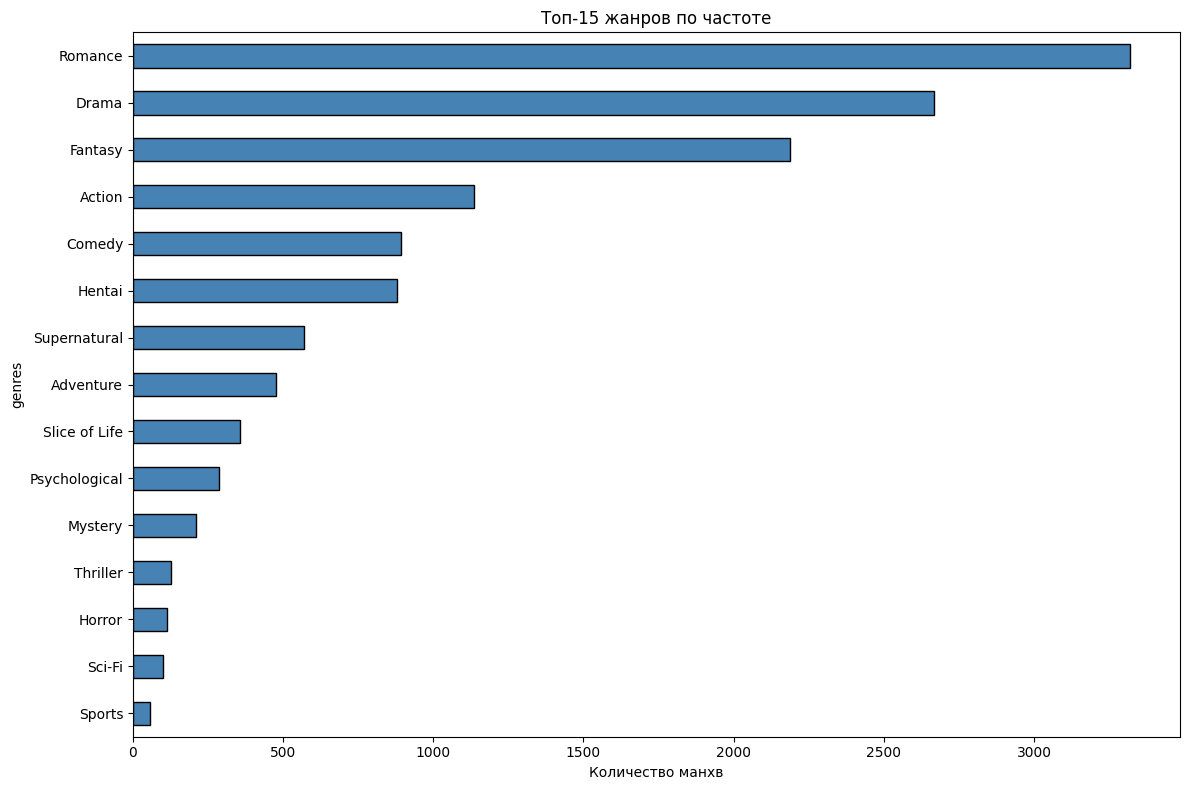

In [50]:
# Если genres ещё в датасете:
# if 'Genres' in manhwa_cd.columns:
# Разбиваем строки по запятой и убираем пробелы
all_genres = manhwa_cd['genres'].dropna().str.split(',').explode()
all_genres = all_genres.str.strip()  # убираем пробелы вокруг названий

    
# Статистика по жанрам
genre_stats = all_genres.value_counts()
    
print("=== Все уникальные жанры ===")
print(f"Всего жанров: {genre_stats.shape[0]}")
print(genre_stats.head(19))

unique_genres = all_genres.unique()

# Преобразуем в обычный Python-список
genre_list = unique_genres.tolist()

print("=== Список уникальных жанров ===")
print(genre_list)
print(f"\nВсего: {len(genre_list)} жанров")

    
# Визуализация топ-15
plt.figure(figsize=(12, 8))
genre_stats.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Количество манхв')
plt.title('Топ-15 жанров по частоте')
plt.gca().invert_yaxis()  # чтобы топ был сверху
plt.tight_layout()
plt.show()

Далее создадим из жанров признаки

In [51]:
print(f"Создание признаков для всех {len(unique_genres)} жанров")

manhwa_genrs = manhwa_cd.copy()

for genre in unique_genres:
    # Создаём колонку: 1 если жанр есть, 0 если нет
    col_name = f'gnr_{genre.lower().replace(" ", "_")}'
    manhwa_genrs[col_name] = manhwa_genrs['genres'].str.contains(genre, na=False, case=False).astype(int)
    print(f"{col_name}: {manhwa_genrs[col_name].sum()} манхв ({manhwa_genrs[col_name].mean()*100:.1f}%)")

# Шаг 3: Добавляем признак "количество жанров"

manhwa_genrs['genre_count'] = manhwa_genrs['genres'].str.split(',').str.len()
print(f"\ngenre_count: диапазон [{manhwa_genrs['genre_count'].min()}, {manhwa_genrs['genre_count'].max()}], среднее {manhwa_genrs['genre_count'].mean():.2f}")



Создание признаков для всех 19 жанров
gnr_action: 1136 манхв (22.8%)
gnr_adventure: 478 манхв (9.6%)
gnr_fantasy: 2187 манхв (43.8%)
gnr_drama: 2667 манхв (53.5%)
gnr_mystery: 211 манхв (4.2%)
gnr_horror: 114 манхв (2.3%)
gnr_psychological: 286 манхв (5.7%)
gnr_romance: 3320 манхв (66.6%)
gnr_thriller: 127 манхв (2.5%)
gnr_supernatural: 570 манхв (11.4%)
gnr_comedy: 891 манхв (17.9%)
gnr_sci-fi: 101 манхв (2.0%)
gnr_sports: 58 манхв (1.2%)
gnr_slice_of_life: 357 манхв (7.2%)
gnr_hentai: 880 манхв (17.6%)
gnr_ecchi: 39 манхв (0.8%)
gnr_music: 23 манхв (0.5%)
gnr_mahou_shoujo: 5 манхв (0.1%)
gnr_mecha: 3 манхв (0.1%)

genre_count: диапазон [1, 7], среднее 2.70


Оригинальный столбец с жанрами удалять не буду - оставлю на всякий случай

In [52]:
manhwa_genrs.head(10)

,year,status,genres,chapters,popularity,score,gnr_action,gnr_adventure,gnr_fantasy,gnr_drama,...,gnr_comedy,gnr_sci-fi,gnr_sports,gnr_slice_of_life,gnr_hentai,gnr_ecchi,gnr_music,gnr_mahou_shoujo,gnr_mecha,genre_count
0,2018,FINISHED,"Action, Adventure, Fantasy",201,265076,84.0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,3
1,2020,RELEASING,"Action, Adventure, Fantasy",0,117235,86.0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,3
2,2010,RELEASING,"Action, Adventure, Drama, Fantasy, Mystery",0,94166,81.0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,5
3,2014,FINISHED,"Drama, Horror, Mystery, Psychological, Romance...",94,72159,83.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6
4,2016,FINISHED,"Adventure, Drama, Psychological",21,59288,85.0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,3
5,2020,RELEASING,"Action, Adventure, Drama, Fantasy, Supernatural",0,58500,83.0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,5
6,2021,FINISHED,"Adventure, Comedy, Fantasy",222,52614,89.0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,3
7,2017,FINISHED,"Drama, Horror, Psychological, Supernatural, Th...",141,51581,81.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5
8,2020,RELEASING,"Action, Drama",0,51505,79.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,2
9,2011,FINISHED,"Action, Adventure, Fantasy",569,51233,76.0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,3


Далее кодируем статус

In [53]:
# Смотрим уникальные значения
print("Уникальные значения status:")
print(manhwa_genrs['status'].value_counts())


Уникальные значения status:
status
FINISHED     3545
RELEASING    1400
CANCELLED      43
Name: count, dtype: int64


Порядка осмысленного нету, посему делаем простой one-hot encoding

In [54]:
manhwa_genrs = pd.get_dummies(manhwa_genrs, columns=['status'], prefix='status', drop_first=False)
# #manhwa_genrs = manhwa_genrs.drop('status', axis=1)

# 2. Находим все новые столбцы со статусом
status_cols = [col for col in manhwa_genrs.columns if col.startswith('status_')]

# 3. Преобразуем их в int
manhwa_genrs[status_cols] = manhwa_genrs[status_cols].astype(int)

manhwa_genrs.head(10)

,year,genres,chapters,popularity,score,gnr_action,gnr_adventure,gnr_fantasy,gnr_drama,gnr_mystery,...,gnr_slice_of_life,gnr_hentai,gnr_ecchi,gnr_music,gnr_mahou_shoujo,gnr_mecha,genre_count,status_CANCELLED,status_FINISHED,status_RELEASING
0,2018,"Action, Adventure, Fantasy",201,265076,84.0,1,1,1,0,0,...,0,0,0,0,0,0,3,0,1,0
1,2020,"Action, Adventure, Fantasy",0,117235,86.0,1,1,1,0,0,...,0,0,0,0,0,0,3,0,0,1
2,2010,"Action, Adventure, Drama, Fantasy, Mystery",0,94166,81.0,1,1,1,1,1,...,0,0,0,0,0,0,5,0,0,1
3,2014,"Drama, Horror, Mystery, Psychological, Romance...",94,72159,83.0,0,0,0,1,1,...,0,0,0,0,0,0,6,0,1,0
4,2016,"Adventure, Drama, Psychological",21,59288,85.0,0,1,0,1,0,...,0,0,0,0,0,0,3,0,1,0
5,2020,"Action, Adventure, Drama, Fantasy, Supernatural",0,58500,83.0,1,1,1,1,0,...,0,0,0,0,0,0,5,0,0,1
6,2021,"Adventure, Comedy, Fantasy",222,52614,89.0,0,1,1,0,0,...,0,0,0,0,0,0,3,0,1,0
7,2017,"Drama, Horror, Psychological, Supernatural, Th...",141,51581,81.0,0,0,0,1,0,...,0,0,0,0,0,0,5,0,1,0
8,2020,"Action, Drama",0,51505,79.0,1,0,0,1,0,...,0,0,0,0,0,0,2,0,0,1
9,2011,"Action, Adventure, Fantasy",569,51233,76.0,1,1,1,0,0,...,0,0,0,0,0,0,3,0,1,0


Далее сделаем масштабирование данных

In [55]:
print("Список колонок с типами данных: ")
manhwa_genrs.dtypes

Список колонок с типами данных: 


year                   int64
genres                   str
chapters               int64
popularity             int64
score                float64
gnr_action             int64
gnr_adventure          int64
gnr_fantasy            int64
gnr_drama              int64
gnr_mystery            int64
gnr_horror             int64
gnr_psychological      int64
gnr_romance            int64
gnr_thriller           int64
gnr_supernatural       int64
gnr_comedy             int64
gnr_sci-fi             int64
gnr_sports             int64
gnr_slice_of_life      int64
gnr_hentai             int64
gnr_ecchi              int64
gnr_music              int64
gnr_mahou_shoujo       int64
gnr_mecha              int64
genre_count            int64
status_CANCELLED       int64
status_FINISHED        int64
status_RELEASING       int64
dtype: object


Диапазоны признаков ДО масштабирования
                   Минимум  Максимум  Диапазон      Среднее  Стд. отклонение
year                   0.0    2026.0    2026.0  2019.669808        40.634173
chapters               0.0     569.0     569.0    56.387731        59.693580
popularity           289.0  265076.0  264787.0  2437.844627      6326.605476
score                 31.0      89.0      58.0    62.686688         7.243636
gnr_action             0.0       1.0       1.0     0.227747         0.419420
gnr_adventure          0.0       1.0       1.0     0.095830         0.294387
gnr_fantasy            0.0       1.0       1.0     0.438452         0.496247
gnr_drama              0.0       1.0       1.0     0.534683         0.498846
gnr_mystery            0.0       1.0       1.0     0.042302         0.201296
gnr_horror             0.0       1.0       1.0     0.022855         0.149456
gnr_psychological      0.0       1.0       1.0     0.057338         0.232510
gnr_romance            0.0       1.0

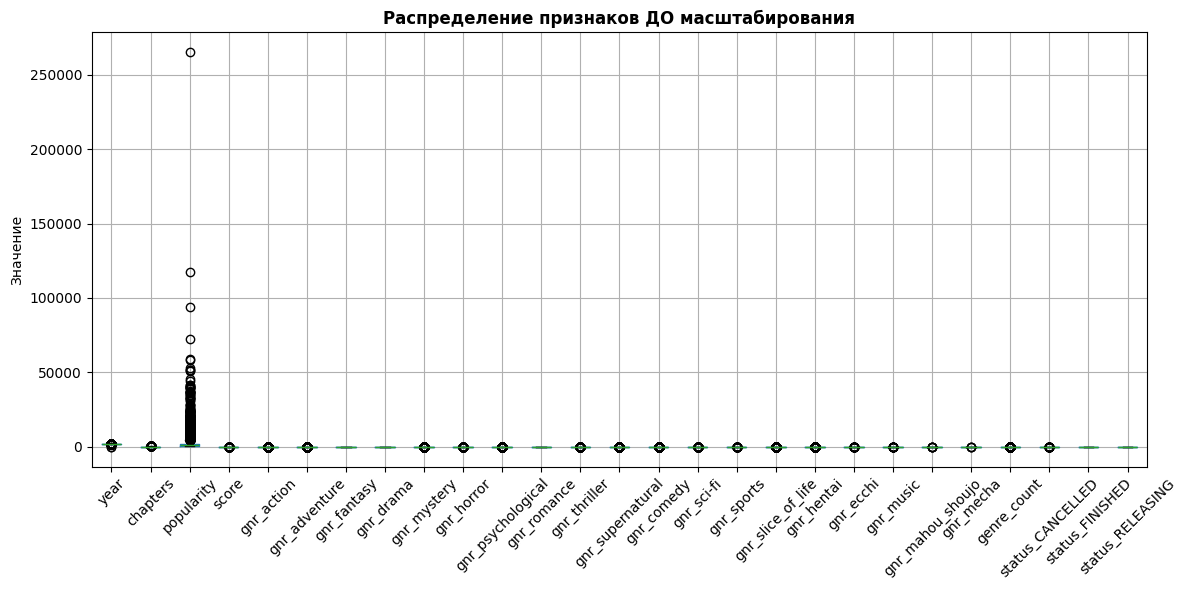

In [56]:
target_col = 'score'
X = manhwa_genrs.select_dtypes(include=[np.number])
#y = manhwa_genrs[target_col]

print("\nДиапазоны признаков ДО масштабирования")
stats_before = pd.DataFrame({
    'Минимум': X.min(),
    'Максимум': X.max(),
    'Диапазон': X.max() - X.min(),
    'Среднее': X.mean(),
    'Стд. отклонение': X.std()
})
print(stats_before.to_string())

# Визуализация до масштабирования
plt.figure(figsize=(12, 6))
X.boxplot(rot=45)
plt.title('Распределение признаков ДО масштабирования', fontweight='bold')
plt.ylabel('Значение')
plt.tight_layout()
plt.show()

Короче говоря, распределение признаков жутко неравномерное.

ещё и выясняется, что в столбце year есть значения 0. Надо от них избавиться.

In [57]:
print('Всего строк: {}'.format(manhwa_genrs.shape[0]))

manhwa_genrs = manhwa_genrs[manhwa_genrs['year'] != 0]

print('Всего строк: {}'.format(manhwa_genrs.shape[0]))

X = manhwa_genrs.select_dtypes(include=[np.number])
y = manhwa_genrs[target_col]

print("\nДиапазоны признаков ДО масштабирования")
stats_before = pd.DataFrame({
    'Минимум': X.min(),
    'Максимум': X.max(),
    'Диапазон': X.max() - X.min(),
    'Среднее': X.mean(),
    'Стд. отклонение': X.std()
})
print(stats_before.to_string())

Всего строк: 4988
Всего строк: 4986

Диапазоны признаков ДО масштабирования
                   Минимум  Максимум  Диапазон      Среднее  Стд. отклонение
year                1993.0    2026.0      33.0  2020.479944         3.821769
chapters               0.0     569.0     569.0    56.410148        59.695053
popularity           289.0  265076.0  264787.0  2438.611913      6327.758195
score                 31.0      89.0      58.0    62.690975         7.241676
gnr_action             0.0       1.0       1.0     0.227637         0.419349
gnr_adventure          0.0       1.0       1.0     0.095668         0.294165
gnr_fantasy            0.0       1.0       1.0     0.438428         0.496244
gnr_drama              0.0       1.0       1.0     0.534697         0.498845
gnr_mystery            0.0       1.0       1.0     0.042318         0.201335
gnr_horror             0.0       1.0       1.0     0.022663         0.148843
gnr_psychological      0.0       1.0       1.0     0.057361         0.232554


Уже похоже на правду

Далее вытащим из датасета X целевую переменную - **score** и разделим таки на обучающую и тестовую выборку исходные данные

In [58]:
from sklearn.model_selection import train_test_split

#print(X.columns.tolist())

X = X.drop('score', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nTrain: {X_train.shape[0]} строк")
print(f"Test: {X_test.shape[0]} строк")



Train: 3988 строк
Test: 998 строк


Теперь проводим масштабирование данных

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame (для удобства)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"\nX_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")


X_train_scaled: (3988, 26)
X_test_scaled: (998, 26)


Теперь займемся обучением модели ближайших соседей (пока с произвольным K)

In [60]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Обучение KNN с произвольным K\n")

K_ARBITRARY = 21  # ЧИСЛО СОСЕДЕЙ

print(f"Выбранное K: {K_ARBITRARY}")

knn = KNeighborsRegressor(n_neighbors=K_ARBITRARY)
knn.fit(X_train_scaled, y_train)

print("Модель обучена!\n")


# Делаем предсказания

y_pred_train = knn.predict(X_train_scaled)  # Предсказания на train
y_pred_test = knn.predict(X_test_scaled)    # Предсказания на test


# Оцениваем качество (метрики для регрессии)

print("Метрики качества\n")

# На тренировочной выборке
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# На тестовой выборке
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"{'Метрика':<15} {'Train':<15} {'Test':<15}")
print("-" * 45)
print(f"{'MAE':<15} {mae_train:<15.4f} {mae_test:<15.4f}")
print(f"{'RMSE':<15} {rmse_train:<15.4f} {rmse_test:<15.4f}")
print(f"{'R^2':<15} {r2_train:<15.4f} {r2_test:<15.4f}")


# Интерпретация результатов

print("\nИнтерпретация\n")
print(f"MAE на тесте = {mae_test:.2f}")
print(f"    В среднем модель ошибается на {mae_test:.2f} балла score")
print(f"\nRMSE на тесте = {rmse_test:.2f}")
print(f"    Среднеквадратичная ошибка: {rmse_test:.2f} балла")
print(f"\nR^2 на тесте = {r2_test:.4f}")
print(f"    Модель объясняет {r2_test*100:.2f}% дисперсии целевой переменной")

# Проверка на переобучение
if r2_train > r2_test + 0.1:
    print("\nВозможное переобучение: R^2 на train значительно выше, чем на test")
else:
    print("\nПереобучение не обнаружено")

Обучение KNN с произвольным K

Выбранное K: 21
Модель обучена!

Метрики качества

Метрика         Train           Test           
---------------------------------------------
MAE             4.5105          4.9309         
RMSE            5.7421          6.3558         
R^2             0.3621          0.2661         

Интерпретация

MAE на тесте = 4.93
    В среднем модель ошибается на 4.93 балла score

RMSE на тесте = 6.36
    Среднеквадратичная ошибка: 6.36 балла

R^2 на тесте = 0.2661
    Модель объясняет 26.61% дисперсии целевой переменной

Переобучение не обнаружено


**Важное наблюдение** - чем выше я ставил (вручную) K_ARBITRARY, тем более низкой становилась разница R^2 у тренировочной и тестовой выборок.

Это объясняется тем, что при малых K растёт сложность модели - она запоминает все значения исходного датасета. А при больших K - модель становится слишком простой и стремится к среднему.

Теперь перейдем к GridSearchCV - это автоматический перебор всех комбинаций гиперпараметров с кросс-валидацией. Т.е. модель сама протестирует разные значения K и скажет, какое лучшее.

Настройка GridSearchCV

Всего комбинаций для проверки: 18

GridSearchCV создан!
Кросс-валидация: 5 фолдов
Параметры для перебора: {'n_neighbors': range(20, 101, 10), 'weights': ['uniform'], 'metric': ['euclidean', 'manhattan']}

Запуск GridSearchCV (может занять какое-то время)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
--------------------------------------------------
 РЕЗУЛЬТАТЫ GridSearchCV

Лучший K: 20
Лучшие веса: uniform
Лучшая метрика: manhattan

R^2 на кросс-валидации: 0.2930

 R^2 на тестовой выборке: 0.2920

Топ-10 комбинаций параметров 
 param_n_neighbors param_weights param_metric  mean_test_score  std_test_score  rank_test_score
                20       uniform    manhattan         0.292994        0.032009                1
                30       uniform    manhattan         0.288725        0.025285                2
                20       uniform    euclidean         0.275058        0.024889                3
                40       uniform    manha

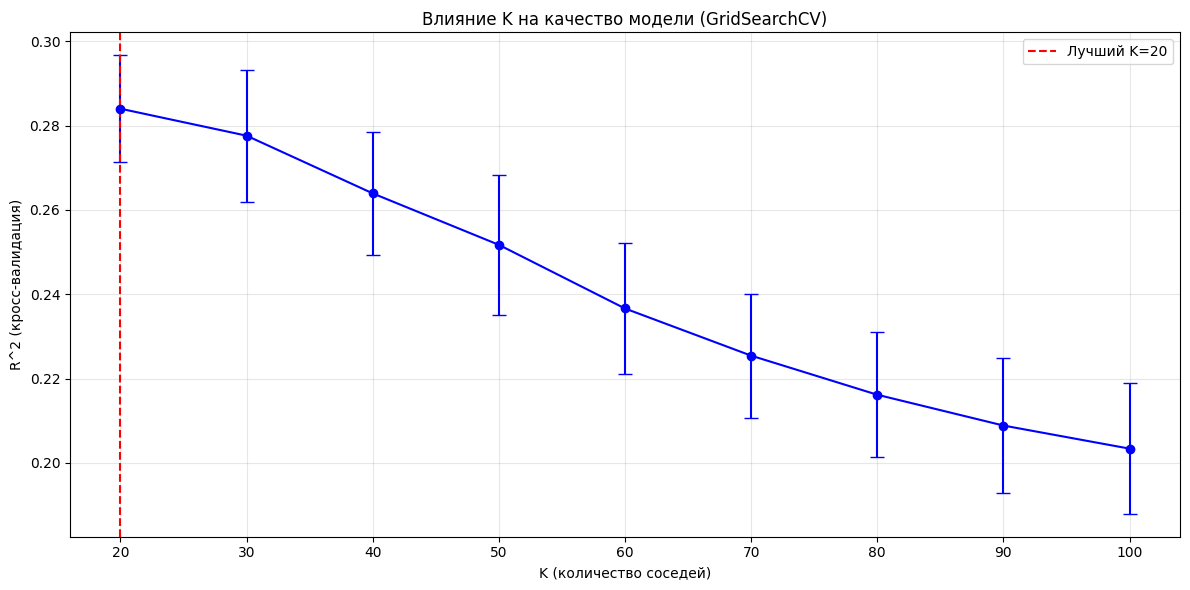

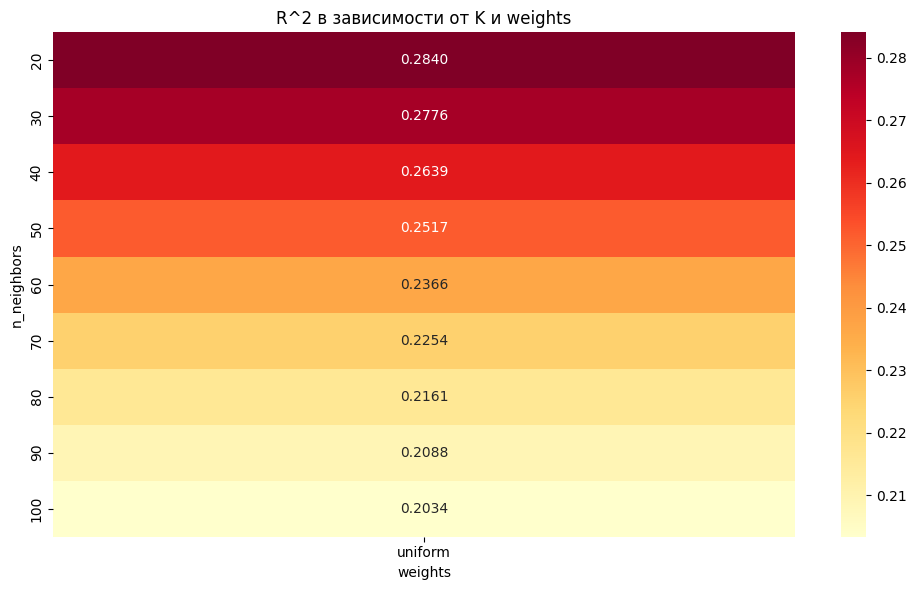

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import seaborn as sns

print("Настройка GridSearchCV\n")

# Параметры для перебора
param_grid = {
    'n_neighbors': range(20, 101, 10),  # значения K
    'weights': ['uniform'],  # как учитывать соседей
    'metric': ['euclidean', 'manhattan']  # тип расстояния
}

print(f"Всего комбинаций для проверки: {len(param_grid['n_neighbors']) * len(param_grid['weights']) * len(param_grid['metric'])}")


# создаём GridSearchCV

knn = KNeighborsRegressor()

grid_search = GridSearchCV(
    estimator=knn,              # модель
    param_grid=param_grid,      # сетка параметров
    cv=5,                       # 5-фолдная кросс-валидация (оптимальное число)
    scoring='r2',               # метрика для оценки (R^2)
    n_jobs=-1,                  # использовать все ядра CPU (для ускорения)
    verbose=1                   # показывать прогресс
)

print("\nGridSearchCV создан!")
print("Кросс-валидация: 5 фолдов")
print(f"Параметры для перебора: {param_grid}")


# запускаем поиск

print("\nЗапуск GridSearchCV (может занять какое-то время)\n")
grid_search.fit(X_train_scaled, y_train)


# Результаты
print("-"*50)
print(" РЕЗУЛЬТАТЫ GridSearchCV")

print(f"\nЛучший K: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшие веса: {grid_search.best_params_['weights']}")
print(f"Лучшая метрика: {grid_search.best_params_['metric']}")
print(f"\nR^2 на кросс-валидации: {grid_search.best_score_:.4f}")


# Оценка на тестовой выборке

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test_scaled)
r2_test = r2_score(y_test, y_pred_test)

print(f"\n R^2 на тестовой выборке: {r2_test:.4f}")


# ШАГ 6: Таблица всех результатов

print("\nТоп-10 комбинаций параметров ")
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

top_10 = results_df[['param_n_neighbors', 'param_weights', 'param_metric', 
                     'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
print(top_10.to_string(index=False))


# Визуализация результатов


# График: R^2 в зависимости от K
plt.figure(figsize=(12, 6))

# Группируем по K (усредняем по остальным параметрам)
k_scores = results_df.groupby('param_n_neighbors')['mean_test_score'].agg(['mean', 'std']).reset_index()

plt.errorbar(k_scores['param_n_neighbors'], k_scores['mean'], 
             yerr=k_scores['std'], capsize=5, marker='o', linestyle='-', color='blue')
plt.axvline(x=grid_search.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Лучший K={grid_search.best_params_["n_neighbors"]}')
plt.xlabel('K (количество соседей)')
plt.ylabel('R^2 (кросс-валидация)')
plt.title('Влияние K на качество модели (GridSearchCV)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Тепловая карта: K vs weights
plt.figure(figsize=(10, 6))
pivot = results_df.pivot_table(values='mean_test_score', 
                                index='param_n_neighbors', 
                                columns='param_weights', 
                                aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('R^2 в зависимости от K и weights')
plt.xlabel('weights')
plt.ylabel('n_neighbors')
plt.tight_layout()
plt.show()

Далее по заданию необходимо было использовать и RandomizedSearchCV

In [62]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


# Создаём распределение параметров

print("\nНастройка RandomizedSearchCV\n")

param_dist = {
    'n_neighbors': randint(40, 101),  # случайное число от 1 до 50
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan']
}


# ШАГ 2: Создаём RandomizedSearchCV

knn = KNeighborsRegressor()

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=30,              # проверить 30 случайных комбинаций
    cv=5,                   # 5-фолдная кросс-валидация
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42     # для повторяемости результатов задаём одинаковое зерно
)

print(f"Количество итераций: 30")
print(f"Кросс-валидация: 5 фолдов")


# запускаем поиск

print("\nЗапуск RandomizedSearchCV\n")
random_search.fit(X_train_scaled, y_train)


# Результаты


print(" РЕЗУЛЬТАТЫ RandomizedSearchCV")


print(f"\nЛучший K: {random_search.best_params_['n_neighbors']}")
print(f"Лучшие веса: {random_search.best_params_['weights']}")
print(f"Лучшая метрика: {random_search.best_params_['metric']}")
print(f"\nR^2 на кросс-валидации: {random_search.best_score_:.4f}")

# Оценка на тесте
best_model_random = random_search.best_estimator_
y_pred_test_random = best_model_random.predict(X_test_scaled)
r2_test_random = r2_score(y_test, y_pred_test_random)
print(f"\nR^2 на тестовой выборке: {r2_test_random:.4f}")


Настройка RandomizedSearchCV

Количество итераций: 30
Кросс-валидация: 5 фолдов

Запуск RandomizedSearchCV

Fitting 5 folds for each of 30 candidates, totalling 150 fits
 РЕЗУЛЬТАТЫ RandomizedSearchCV

Лучший K: 41
Лучшие веса: uniform
Лучшая метрика: manhattan

R^2 на кросс-валидации: 0.2735

R^2 на тестовой выборке: 0.2824


Наконец, сравним все модели!

--------------------------------------------------
СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ 

            Модель  R^2 Train  R^2 Test  Разница  Лучший K
 K=5 (произвольно)   0.540355  0.271402 0.268953         5
     K=18 (ручной)   0.362149  0.266148 0.096000        18
      GridSearchCV   0.292994  0.292025 0.092718        20
RandomizedSearchCV   0.273519  0.282364 0.045497        41


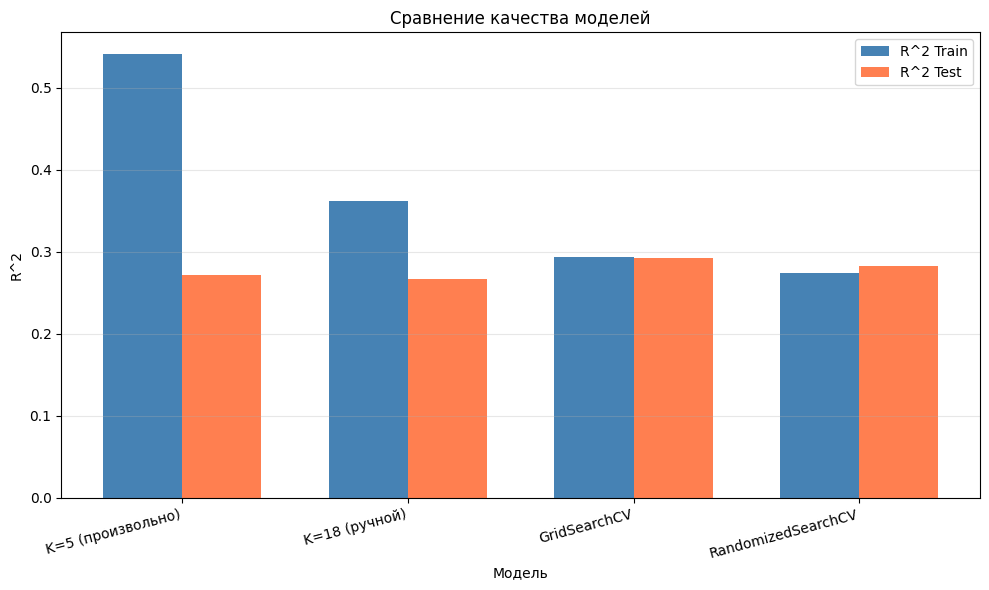


--------------------------------------------------
 ВЫВОДЫ

Лучшая модель: GridSearchCV
R^2 на тесте: 0.2920
Разница train/test: 0.0927
Модель не переобучается (разница < 0.1)


In [63]:
# Сводная таблица всех результатов

print("-"*50)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ")


# Произвольная модель (K=5)
knn_arbitrary = KNeighborsRegressor(n_neighbors=5)
knn_arbitrary.fit(X_train_scaled, y_train)
r2_train_arb = r2_score(y_train, knn_arbitrary.predict(X_train_scaled))
r2_test_arb = r2_score(y_test, knn_arbitrary.predict(X_test_scaled))

# Произвольная модель (K=18 - лучшая ручная)
knn_manual = KNeighborsRegressor(n_neighbors=21)
knn_manual.fit(X_train_scaled, y_train)
r2_train_man = r2_score(y_train, knn_manual.predict(X_train_scaled))
r2_test_man = r2_score(y_test, knn_manual.predict(X_test_scaled))

# GridSearchCV
r2_train_grid = r2_score(y_train, best_model.predict(X_train_scaled))
r2_test_grid = r2_test

# RandomizedSearchCV
r2_train_rand = r2_score(y_train, best_model_random.predict(X_train_scaled))
r2_test_rand = r2_test_random

comparison = pd.DataFrame({
    'Модель': ['K=5 (произвольно)', f'K=18 (ручной)', 'GridSearchCV', 'RandomizedSearchCV'],
    'R^2 Train': [r2_train_arb, r2_train_man, grid_search.best_score_, random_search.best_score_],
    'R^2 Test': [r2_test_arb, r2_test_man, r2_test_grid, r2_test_rand],
    'Разница': [r2_train_arb - r2_test_arb, r2_train_man - r2_test_man, 
                r2_train_grid - r2_test_grid, r2_train_rand - r2_test_rand],
    'Лучший K': [5, 18, grid_search.best_params_['n_neighbors'], 
                 random_search.best_params_['n_neighbors']]
})

print("\n" + comparison.to_string(index=False))


# Визуализация сравнения

plt.figure(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35

plt.bar(x - width/2, comparison['R^2 Train'], width, label='R^2 Train', color='steelblue')
plt.bar(x + width/2, comparison['R^2 Test'], width, label='R^2 Test', color='coral')

plt.xlabel('Модель')
plt.ylabel('R^2')
plt.title('Сравнение качества моделей')
plt.xticks(x, comparison['Модель'], rotation=15, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Вывод

print("\n" + "-"*50)
print(" ВЫВОДЫ")

best_method = comparison.loc[comparison['R^2 Test'].idxmax()]
print(f"\nЛучшая модель: {best_method['Модель']}")
print(f"R^2 на тесте: {best_method['R^2 Test']:.4f}")
print(f"Разница train/test: {best_method['Разница']:.4f}")

if best_method['Разница'] < 0.1:
    print("Модель не переобучается (разница < 0.1)")
else:
    print("!! Возможное переобучение (разница >= 0.1)")

При первоначальном запуске GridSearchCV с диапазоном K=[3–30] было обнаружено сильное переобучение: R^2 на тренировочной выборке достигал 0.999, тогда как на тестовой — лишь 0.32 (разница 0.68). Это объясняется тем, что малые значения K (11–24) позволяют модели «запоминать» тренировочные данные вместо обучения общим закономерностям.

Диапазон поиска был расширен до K=[20–100] c шагом 10, что соответствует эмпирическому правилу K ≈ sqrt(n) для выборки из ~4900 объектов. Также были зафиксированы параметры weights='uniform' и metric='euclidean' для снижения риска переобучения.
